# 06 — Убиваем конфаунд расположения

nb05: на касании реального уровня объём выше, чем на случайной цене (1.33 vs 1.06).
Но наивный fake брался из `close` → сидит в СЕРЕДИНЕ диапазона, а реальные пивоты — на
КРАЯХ. Если у краёв объём выше сам по себе, разрыв — артефакт расположения, не «память».

**Тест:** (1) есть ли вообще конфаунд (объём по позиции-в-диапазоне); (2) matched-fake —
позиции реальных уровней перемешаны между событиями и возвращены в диапазон (то же
распределение расположения, но не пивот); (3) real vs matched-fake vs naive-fake.
Если real > matched-fake выживает → это память о ЦЕНЕ, а не край диапазона.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd
rng = np.random.default_rng(0)
full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::3][:50]
START, END, TF = "2024-01-01", "2025-07-01", "1h"
TOL = 0.0015; CD = 6; LIFE = 720; W = 720
print(len(UNIV), "symbols")

47 symbols


In [2]:
def pivots(df, k):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    hi = np.zeros(n, bool); lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i-k:i+k+1]; wL = l[i-k:i+k+1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: lo[i] = True
    return hi, lo

def cluster_segments(df, k=10, R=24, life=LIFE, tol=0.006, mint=3):
    hi, lo = pivots(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); conf = []
    for i in np.where(hi)[0]: conf.append((i+k, h[i]))
    for i in np.where(lo)[0]: conf.append((i+k, l[i]))
    conf = np.array(sorted(conf)) if conf else np.empty((0, 2)); segs = []
    for r in range(k, n, R):
        if len(conf) == 0: break
        m = (conf[:, 0] <= r) & (conf[:, 0] > r - life); px = np.sort(conf[m, 1])
        if len(px) < mint: continue
        cl = [[px[0]]]
        for x in px[1:]:
            if (x - cl[-1][0]) / cl[-1][0] <= tol: cl[-1].append(x)
            else: cl.append([x])
        for c in cl:
            if len(c) >= mint: segs.append((float(np.mean(c)), r, min(r+R, n), len(c)))
    return segs

def touches(df, segs, tol=TOL):
    c = df["close"].to_numpy(); h = df["high"].to_numpy(); l = df["low"].to_numpy()
    best = {}
    for L, a, b, strg in segs:
        a = max(a, 1)
        for t in range(a, b):
            if c[t-1] < L*(1-tol) and h[t] >= L*(1-tol):
                d = abs(h[t]-L)/L; key=(t,"res")
                if key not in best or d < best[key][1]: best[key] = (d, L)
            elif c[t-1] > L*(1+tol) and l[t] <= L*(1+tol):
                d = abs(l[t]-L)/L; key=(t,"sup")
                if key not in best or d < best[key][1]: best[key] = (d, L)
    out = sorted((t, side, L) for (t, side), (d, L) in best.items())
    kept = []; last = -10**9
    for t, side, L in out:
        if t - last >= CD: kept.append((t, side, L)); last = t
    return kept

In [3]:
# pooled: does volume rise toward range edges? (establish the confound)
conf_rows = []; ev_rows = []
for si, sym in enumerate(UNIV):
    df = ohlcv(sym, START, END, TF)
    if len(df) < W + 300: continue
    c = df["close"].to_numpy(); v = df["volume"].to_numpy(); n = len(df)
    hi_w = pd.Series(df["high"]).rolling(W).max().to_numpy()
    lo_w = pd.Series(df["low"]).rolling(W).min().to_numpy()
    vmed = pd.Series(v).rolling(168, min_periods=24).median().to_numpy()
    span = hi_w - lo_w
    posbar = (c - lo_w) / np.where(span > 0, span, np.nan)
    vs = v / vmed
    ok = np.isfinite(posbar) & np.isfinite(vs)
    conf_rows.append(pd.DataFrame({"pos": posbar[ok], "vs": vs[ok]}))
    # real levels with position-in-range; matched-fake = permuted positions
    real = [s for s in cluster_segments(df) if s[1] >= W and span[s[1]] > 0]
    if not real: continue
    pos_real = np.array([(L - lo_w[a]) / span[a] for (L, a, b, strg) in real])
    pos_perm = rng.permutation(pos_real)
    matched = [(lo_w[a] + pos_perm[i] * span[a], a, b, strg) for i, (L, a, b, strg) in enumerate(real)]
    naive = [(float(rng.choice(c[a:b])), a, b, strg) for (L, a, b, strg) in real]
    for kind, segs in [("real", real), ("matched", matched), ("naive", naive)]:
        for t, side, L in touches(df, segs):
            if t < W or not vmed[t] > 0 or not span[t] > 0: continue
            ev_rows.append(dict(kind=kind, vsurge=v[t]/vmed[t], pos=(L-lo_w[t])/span[t]))
    if (si+1) % 15 == 0: print(f"  {si+1}/{len(UNIV)}")

C = pd.concat(conf_rows, ignore_index=True)
E = pd.DataFrame(ev_rows)
C["pbin"] = pd.cut(C.pos.clip(0, 1), np.linspace(0, 1, 11))
confound = C.groupby("pbin", observed=True).vs.median()
print("events:", E.kind.value_counts().to_dict())
print("\nmedian vsurge by kind:")
print(E.groupby("kind").vsurge.agg(["size", "median", "mean"]).round(3).to_string())
print("\nmedian position-in-range by kind (should match real~matched):")
print(E.groupby("kind").pos.median().round(3).to_string())

  15/47


  30/47


  45/47


events: {'naive': 80775, 'matched': 26439, 'real': 25778}

median vsurge by kind:
          size  median   mean
kind                         
matched  26439   1.380  3.713
naive    80775   1.056  2.428
real     25778   1.332  3.197

median position-in-range by kind (should match real~matched):
kind
matched    0.405
naive      0.374
real       0.405


[saved] notebooks\levels\_out\06_confound.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/06_confound.png')

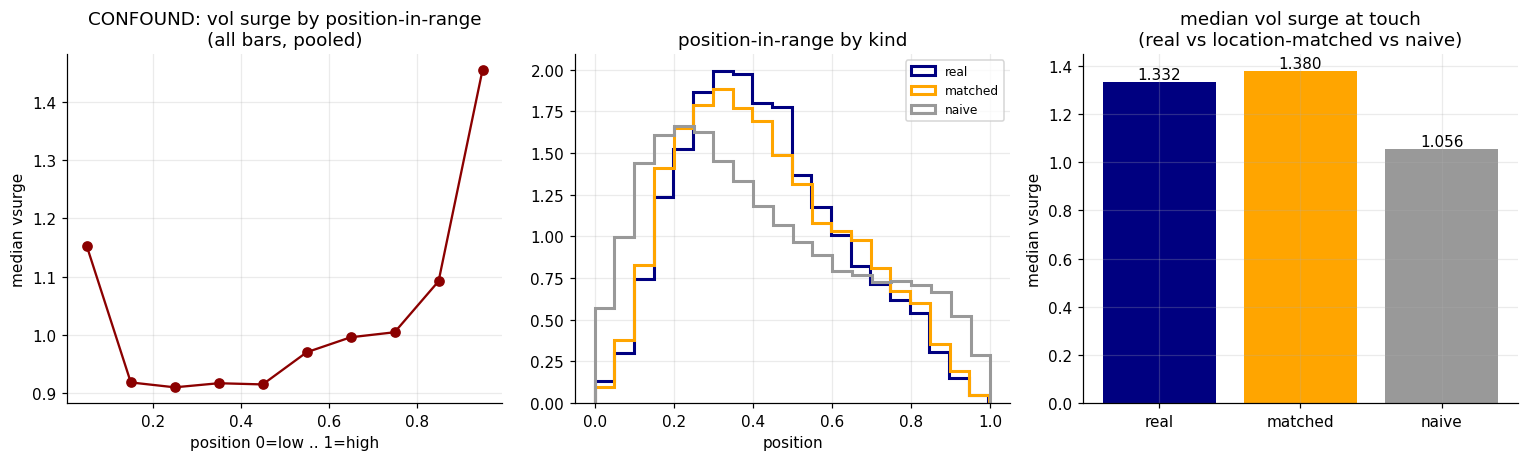

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.3))
# (1) confound: vsurge by position in range
ax[0].plot([iv.mid for iv in confound.index], confound.values, "o-", color="darkred")
ax[0].set_title("CONFOUND: vol surge by position-in-range\n(all bars, pooled)")
ax[0].set_xlabel("position 0=low .. 1=high"); ax[0].set_ylabel("median vsurge")
# (2) position distributions real vs matched (should overlap) vs naive (mid)
for k, col in [("real", "navy"), ("matched", "orange"), ("naive", "0.6")]:
    ax[1].hist(E[E.kind == k].pos.clip(0, 1), bins=20, density=True, histtype="step", lw=2, color=col, label=k)
ax[1].set_title("position-in-range by kind"); ax[1].set_xlabel("position"); ax[1].legend(fontsize=8)
# (3) the verdict: median vsurge real vs matched vs naive
med = E.groupby("kind").vsurge.median().reindex(["real", "matched", "naive"])
ax[2].bar(med.index, med.values, color=["navy", "orange", "0.6"])
for i, val in enumerate(med.values): ax[2].text(i, val, f"{val:.3f}", ha="center", va="bottom")
ax[2].set_title("median vol surge at touch\n(real vs location-matched vs naive)"); ax[2].set_ylabel("median vsurge")
show("06_confound")

## Verdict

- Если **real > matched** (а matched имеет то же распределение позиции) → объёмный след
  — это именно ПАМЯТЬ о цене уровня, не край диапазона. Феномен подтверждён строго.
- Если **real ≈ matched** (и оба > naive) → разрыв из nb05 был артефактом расположения:
  объём выше у краёв, а сам уровень ничего не добавляет. Феномен — иллюзия конфаунда.
- Средняя панель — sanity: real и matched должны накладываться по позиции; naive — горбом в середине.